# CPE393: Final Group Project — Sport and Health: Predicting Fitness Level from Daily Activity and Lifestyle Data

**Group:** IUTO
**Members:** Leni Chabilan | Romain Mechain | Kylian Riberou
**Course:** CPE393 — Introduction to Data Science with Python, Summer 2026, KMUTT

**Project type:** Regression

This notebook predicts a continuous daily **fitness score** (`fitness_level`, range 0–22) from everyday activity and lifestyle indicators (exercise duration, intensity, steps, sleep, stress, hydration) collected from 3,000 participants over 687,701 daily records in 2024. We follow the full workflow required by the course guidelines: problem definition, data cleaning, EDA, visualization, feature engineering, model training (3 regression models), evaluation, and a Responsible AI discussion.

## 0. Setup and Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

# Fixed random state for reproducibility (per project requirements)
RANDOM_STATE = 42

os.makedirs("figures", exist_ok=True)
pd.set_option("display.max_columns", 30)

## 1. Problem Definition

**Problem statement:** Fitness is shaped by many everyday habits at once — exercise frequency, duration and intensity, daily step count, sleep, stress, and hydration — but the combined effect of these factors is rarely made visible in a simple, data-driven way. This project asks: **which lifestyle and activity factors most influence a person's fitness level, and how accurately can we predict that fitness level from daily habits alone?**

**Motivation:** Wearable devices and health apps now collect this kind of daily data at scale. Understanding which everyday habits actually move the needle on fitness (as opposed to habits that *feel* important but show little real effect) has practical value for personal health coaching, app design, and public-health communication — provided the conclusions are reported honestly rather than overstated.

**Target variable:** `fitness_level` — a continuous daily fitness score (observed range ≈ 0–22 in this dataset). This is a **regression** problem.

**Expected outcome:** Based on domain intuition, we expect exercise duration, intensity, and step count to be the strongest predictors. We anticipate **moderate** predictive performance rather than a perfect model, since a single fitness score cannot capture every aspect of a person's real-world health and situation (stressful work, environment, genetics, etc.). As required by the course's Responsible AI policy, we report whether the data actually support this hypothesis — including when they do not.

## 2. Dataset Description

- **Source:** Public health & fitness dataset (CSV), provided as `data/health_fitness_dataset.csv`.
  ⚠️ **Action needed from the group:** we could not verify an exact, citable Kaggle (or other) listing URL for this exact file from its column structure alone. Please paste the **exact dataset URL and license/usage terms** here (and in `data/data_link.txt` / `README.md`) before submission — the guidelines explicitly require reporting the source URL and license, and we should never guess or invent one.
- **Description:** Daily wearable/health-tracking records for a cohort of participants, combining daily activity logs (exercise type, duration, intensity, calories, heart rate, steps) with slower-changing health and demographic attributes (age, gender, height, BMI, resting heart rate, blood pressure, smoking status, diagnosed health conditions).
- **Number of rows:** 687,701 daily records.
- **Number of columns:** 22.
- **Number of unique participants:** 3,000 (≈198–261 records per participant, i.e. roughly 7–9 months of near-daily tracking each, across the period 2024-01-01 to 2024-12-25).
- **Target variable:** `fitness_level` (continuous, regression).
- **File format:** CSV, one row per participant per tracked day.
- **Key limitations identified up front (expanded in Section 10):**
  - The dataset is very likely **simulated/synthetic** rather than collected from real devices — several variables follow suspiciously deterministic patterns (see Section 4.6 and 8.2). This matters for how strongly we can trust any conclusion as "real-world."
  - `health_condition` is mostly empty (no diagnosed condition), which is normal, not a data quality problem.
  - Static attributes (age, height, BMI, resting heart rate, blood pressure, gender, smoking status) are recorded identically on every row for a given participant — they describe the person, not the day.

In [2]:
# Load dataset
df = pd.read_csv("data/health_fitness_dataset.csv", parse_dates=["date"])
df.head()

,participant_id,date,age,gender,height_cm,weight_kg,activity_type,duration_minutes,intensity,calories_burned,avg_heart_rate,hours_sleep,stress_level,daily_steps,hydration_level,bmi,resting_heart_rate,blood_pressure_systolic,blood_pressure_diastolic,health_condition,smoking_status,fitness_level
0,1,2024-01-01,56,F,165.3,53.7,Dancing,41,Low,3.3,103,6.6,3,7128,1.5,19.6,69.5,110.7,72.9,NaN,Never,0.04
1,1,2024-01-04,56,F,165.3,53.9,Swimming,28,Low,2.9,102,8.1,7,7925,1.8,19.6,69.5,110.7,72.9,NaN,Never,0.07
2,1,2024-01-05,56,F,165.3,54.2,Swimming,21,Medium,2.6,126,6.2,7,7557,2.7,19.6,69.5,110.7,72.9,NaN,Never,0.09
3,1,2024-01-07,56,F,165.3,54.4,Weight Training,99,Medium,10.7,141,7.2,8,11120,2.6,19.6,69.5,110.7,72.9,NaN,Never,0.21
4,1,2024-01-09,56,F,165.3,54.7,Swimming,100,Medium,12.7,112,7.1,1,5406,1.5,19.6,69.5,110.7,72.9,NaN,Never,0.33


In [3]:
# Basic structural overview
print("Shape:", df.shape)
df.info()

Shape: (687701, 22)
<class 'pandas.DataFrame'>
RangeIndex: 687701 entries, 0 to 687700
Data columns (total 22 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   participant_id            687701 non-null  int64         
 1   date                      687701 non-null  datetime64[us]
 2   age                       687701 non-null  int64         
 3   gender                    687701 non-null  str           
 4   height_cm                 687701 non-null  float64       
 5   weight_kg                 687701 non-null  float64       
 6   activity_type             687701 non-null  str           
 7   duration_minutes          687701 non-null  int64         
 8   intensity                 687701 non-null  str           
 9   calories_burned           687701 non-null  float64       
 10  avg_heart_rate            687701 non-null  int64         
 11  hours_sleep               687701 non-null  float64      

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
participant_id,687701.0,NaN,NaN,NaN,1499.781828,1.0,749.0,1499.0,2249.0,3000.0,865.997215
date,687701,NaN,NaN,NaN,2024-06-16 18:44:21.629981,2024-01-01 00:00:00,2024-03-21 00:00:00,2024-06-06 00:00:00,2024-09-11 00:00:00,2024-12-25 00:00:00,NaN
age,687701.0,NaN,NaN,NaN,41.658602,18.0,30.0,42.0,53.0,64.0,13.58177
gender,687701,3,F,338856,NaN,NaN,NaN,NaN,NaN,NaN,NaN
height_cm,687701.0,NaN,NaN,NaN,168.587699,145.0,161.7,168.2,175.3,198.5,9.140811
weight_kg,687701.0,NaN,NaN,NaN,94.921981,45.3,78.2,94.6,110.5,188.4,22.461801
activity_type,687701,10,Yoga,69961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration_minutes,687701.0,NaN,NaN,NaN,70.011671,20.0,45.0,70.0,95.0,120.0,29.147251
intensity,687701,3,Medium,343433,NaN,NaN,NaN,NaN,NaN,NaN,NaN
calories_burned,687701.0,NaN,NaN,NaN,15.381302,0.8,7.8,13.0,20.7,92.0,9.985552


## 3. Preprocessing and Cleaning

Document every decision made below (why a column was dropped, how missing values were handled, etc.) — this is graded explicitly.

### 3.1 Missing Values

In [5]:
missing = df.isnull().sum()
missing[missing > 0]

health_condition    490275
dtype: int64

**Decision:** `health_condition` is the only column with missing values (490,275 / 687,701 ≈ 71.3%). After inspection, the missing values are **not random data-collection gaps** — `NaN` here simply means *no diagnosed condition was reported* for that participant, alongside the three diagnosed categories `Diabetes`, `Hypertension`, and `Asthma`. Dropping these rows or imputing a fake diagnosis would be incorrect; instead we recode `NaN` to an explicit `"None"` category, which is also safer for the Responsible AI discussion (Section 10) since it keeps the absence of a diagnosis visible and auditable rather than hidden inside a generic "missing" bucket.

In [6]:
df["health_condition"] = df["health_condition"].fillna("None")
df["health_condition"].value_counts(dropna=False)

health_condition
None            490275
Hypertension     99437
Diabetes         64754
Asthma           33235
Name: count, dtype: int64

### 3.2 Duplicates

In [7]:
n_dupes = df.duplicated().sum()
print("Fully duplicated rows:", n_dupes)
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

Fully duplicated rows: 0


Shape after dropping duplicates: (687701, 22)


**Decision:** No fully duplicated rows were found. The `drop_duplicates()` call is kept anyway as a safety net for reproducibility if the raw file is regenerated or re-exported.

### 3.3 Data Types and Inconsistent Formats

In [8]:
df.dtypes

participant_id                       int64
date                        datetime64[us]
age                                  int64
gender                                 str
height_cm                          float64
weight_kg                          float64
activity_type                          str
duration_minutes                     int64
intensity                              str
calories_burned                    float64
avg_heart_rate                       int64
hours_sleep                        float64
stress_level                         int64
daily_steps                          int64
hydration_level                    float64
bmi                                float64
resting_heart_rate                 float64
blood_pressure_systolic            float64
blood_pressure_diastolic           float64
health_condition                       str
smoking_status                         str
fitness_level                      float64
dtype: object

In [9]:
# `date` was already parsed as datetime at load time. Cast low-cardinality text columns to
# pandas 'category' dtype: this is both more memory-efficient (important at ~690k rows) and
# makes downstream encoding/EDA steps faster and less error-prone.
cat_cols = ["gender", "activity_type", "intensity", "health_condition", "smoking_status"]
for c in cat_cols:
    df[c] = df[c].astype("category")

print("Memory before/after category cast — see df.info(memory_usage='deep') below")
df.info(memory_usage="deep")

Memory before/after category cast — see df.info(memory_usage='deep') below
<class 'pandas.DataFrame'>
RangeIndex: 687701 entries, 0 to 687700
Data columns (total 22 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   participant_id            687701 non-null  int64         
 1   date                      687701 non-null  datetime64[us]
 2   age                       687701 non-null  int64         
 3   gender                    687701 non-null  category      
 4   height_cm                 687701 non-null  float64       
 5   weight_kg                 687701 non-null  float64       
 6   activity_type             687701 non-null  category      
 7   duration_minutes          687701 non-null  int64         
 8   intensity                 687701 non-null  category      
 9   calories_burned           687701 non-null  float64       
 10  avg_heart_rate            687701 non-null  int64         
 11  h

**Decision:** No further type conversion is necessary — numeric columns were already correctly inferred as `int64`/`float64` on load. `date` is now a proper `datetime64`, which lets us safely derive time-based features later (Section 6) instead of treating dates as opaque strings.

### 3.4 Outliers

In [10]:
num_cols_check = ["age","height_cm","weight_kg","duration_minutes","calories_burned",
                  "avg_heart_rate","hours_sleep","stress_level","daily_steps","hydration_level",
                  "bmi","resting_heart_rate","blood_pressure_systolic","blood_pressure_diastolic",
                  "fitness_level"]

outlier_report = []
for c in num_cols_check:
    q1, q3 = df[c].quantile(0.25), df[c].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df[c] < lo) | (df[c] > hi)).sum()
    outlier_report.append([c, df[c].min(), df[c].max(), round(lo,1), round(hi,1), n_out, round(100*n_out/len(df),2)])

outlier_df = pd.DataFrame(outlier_report, columns=["column","min","max","iqr_low","iqr_high","n_outliers","pct_outliers"])
outlier_df.sort_values("pct_outliers", ascending=False)

,column,min,max,iqr_low,iqr_high,n_outliers,pct_outliers
4,calories_burned,0.80,92.00,-11.5,40.0,17441,2.54
13,blood_pressure_diastolic,53.70,112.10,57.9,102.4,6107,0.89
6,hours_sleep,4.00,10.00,4.5,9.6,5897,0.86
10,bmi,14.20,38.80,12.6,32.6,4147,0.60
11,resting_heart_rate,51.10,87.10,56.0,84.0,3738,0.54
12,blood_pressure_systolic,78.00,152.70,92.2,147.9,3602,0.52
8,daily_steps,-419.00,17241.00,2967.0,14263.0,3094,0.45
5,avg_heart_rate,82.00,206.00,79.0,183.0,1867,0.27
2,weight_kg,45.30,188.40,29.8,159.0,1706,0.25
1,height_cm,145.00,198.50,141.3,195.7,460,0.07


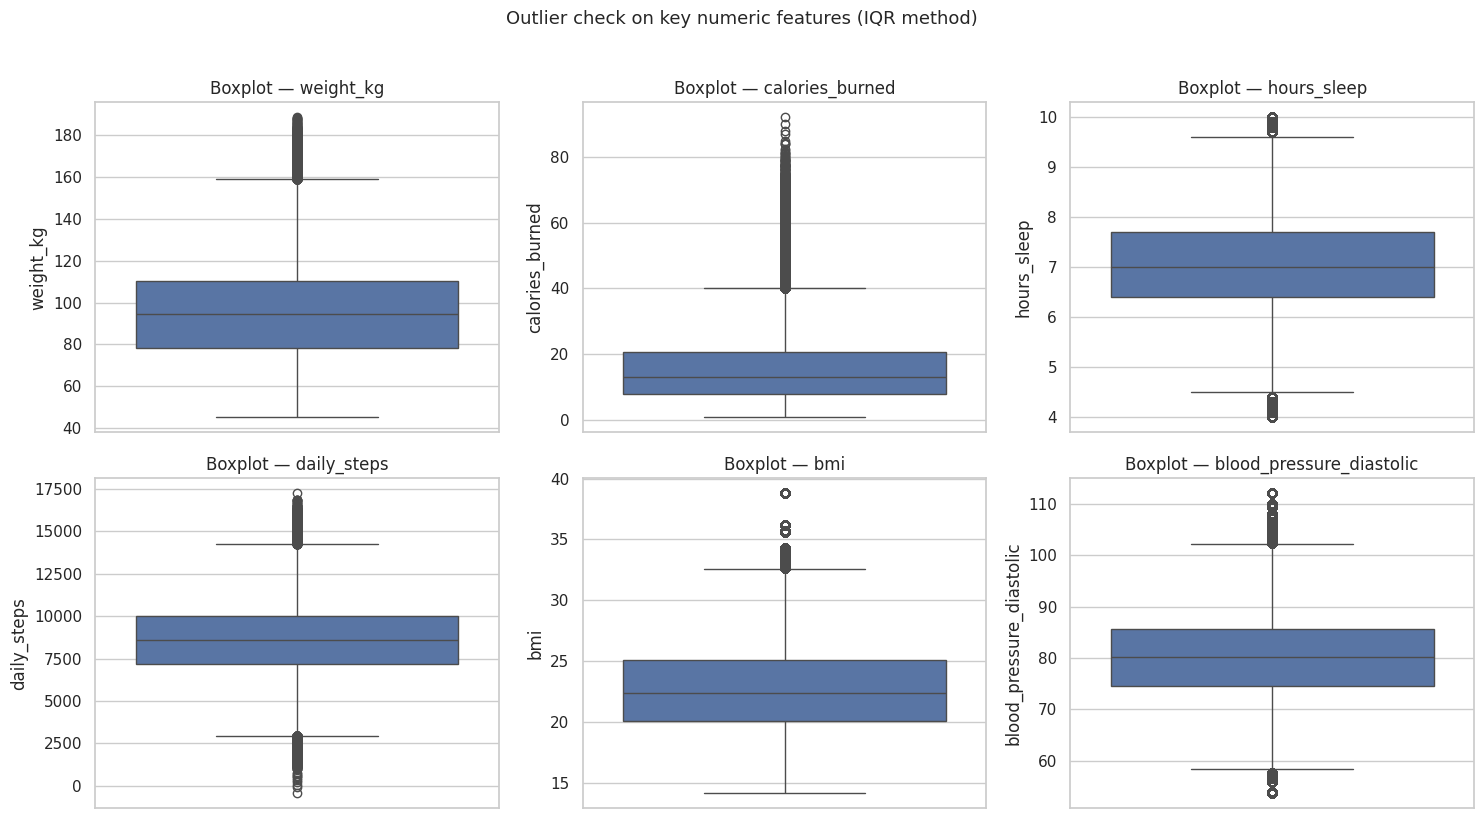

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.ravel(), ["weight_kg","calories_burned","hours_sleep","daily_steps","bmi","blood_pressure_diastolic"]):
    sns.boxplot(y=df[c], ax=ax, color="#4C72B0")
    ax.set_title(f"Boxplot — {c}")
fig.suptitle("Outlier check on key numeric features (IQR method)", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("figures/outlier_boxplots.png", bbox_inches="tight")
plt.show()

In [12]:
# A physically impossible value: daily_steps cannot be negative.
print("Rows with negative daily_steps:", (df["daily_steps"] < 0).sum())
df[df["daily_steps"] < 0][["participant_id","date","daily_steps"]]

Rows with negative daily_steps: 2


,participant_id,date,daily_steps
207781,905,2024-10-01,-419
360838,1573,2024-10-14,-81


In [13]:
# Decision: clip the (very rare) negative step counts to 0 rather than dropping the rows,
# since every other field in those records is valid and informative.
df["daily_steps"] = df["daily_steps"].clip(lower=0)
print("Remaining negative daily_steps:", (df["daily_steps"] < 0).sum())

Remaining negative daily_steps: 0


**Decision summary for outliers:** Every column except `daily_steps` shows between 0% and 2.5% of points flagged by the standard 1.5×IQR rule (e.g. `calories_burned` 2.5%, `blood_pressure_diastolic` 0.9%). Given the large, biologically diverse population (3,000 adults aged 18–64 doing 10 different activity types at 3 intensities), these flagged points sit within physiologically plausible ranges (e.g. blood pressure up to ~150/112, heart rate up to 206 bpm during high-intensity exercise) — they look like genuine biological variation, not measurement errors, so **we keep them rather than removing or capping them**. The one true data-quality issue found was **two rows with negative `daily_steps`** (an impossible value), which we corrected by clipping to 0.

### 3.5 Unnecessary Columns

In [14]:
# participant_id is not a predictive feature (it is an arbitrary identifier), but we deliberately
# KEEP it in the working dataframe — it is required later to perform a participant-level train/test
# split that avoids data leakage (Section 7). It will be excluded from the model's feature matrix
# directly, not dropped from df.
print("participant_id is retained for grouping purposes only — excluded explicitly from X in Section 7.")
df.shape

participant_id is retained for grouping purposes only — excluded explicitly from X in Section 7.


(687701, 22)

## 4. Exploratory Data Analysis (EDA)

Use descriptive statistics and visual exploration to understand distributions, relationships, trends, and possible issues.

### 4.1 Descriptive Statistics

In [15]:
df[num_cols_check].describe().T

,count,mean,std,min,25%,50%,75%,max
age,687701.0,41.658602,13.581770,18.00,30.00,42.00,53.00,64.00
height_cm,687701.0,168.587699,9.140811,145.00,161.70,168.20,175.30,198.50
weight_kg,687701.0,94.921981,22.461801,45.30,78.20,94.60,110.50,188.40
duration_minutes,687701.0,70.011671,29.147251,20.00,45.00,70.00,95.00,120.00
calories_burned,687701.0,15.381302,9.985552,0.80,7.80,13.00,20.70,92.00
avg_heart_rate,687701.0,131.454165,17.814744,82.00,118.00,130.00,144.00,206.00
hours_sleep,687701.0,7.048799,0.972068,4.00,6.40,7.00,7.70,10.00
stress_level,687701.0,5.252389,2.770029,1.00,3.00,5.00,8.00,10.00
daily_steps,687701.0,8628.371646,2054.753491,0.00,7203.00,8607.00,10027.00,17241.00
hydration_level,687701.0,2.499427,0.579050,1.50,2.00,2.50,3.00,3.50


### 4.2 Target Variable Distribution

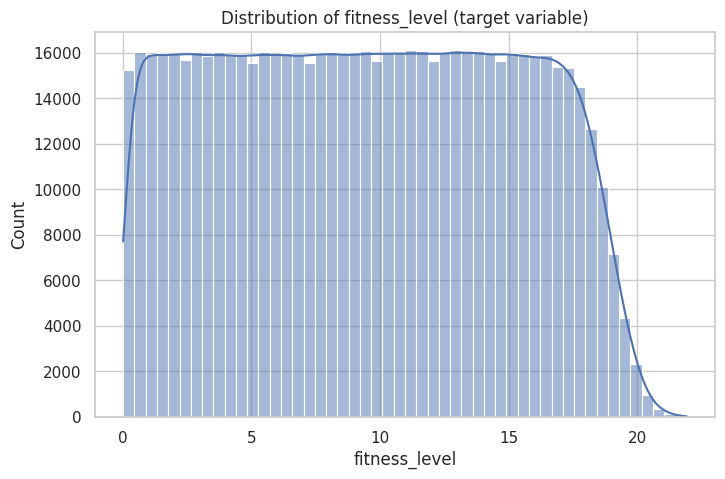

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df["fitness_level"], kde=True, color="#4C72B0", bins=50)
plt.title("Distribution of fitness_level (target variable)")
plt.xlabel("fitness_level")
plt.ylabel("Count")
plt.savefig("figures/target_distribution.png", bbox_inches="tight")
plt.show()

**Interpretation:** `fitness_level` is close to uniformly spread between 0 and ~22, with a slight bulge around the middle. There is no extreme skew and no obvious floor/ceiling clipping, so no transformation (e.g. log) of the target is needed before modeling.

### 4.3 Correlation Analysis (numeric features)

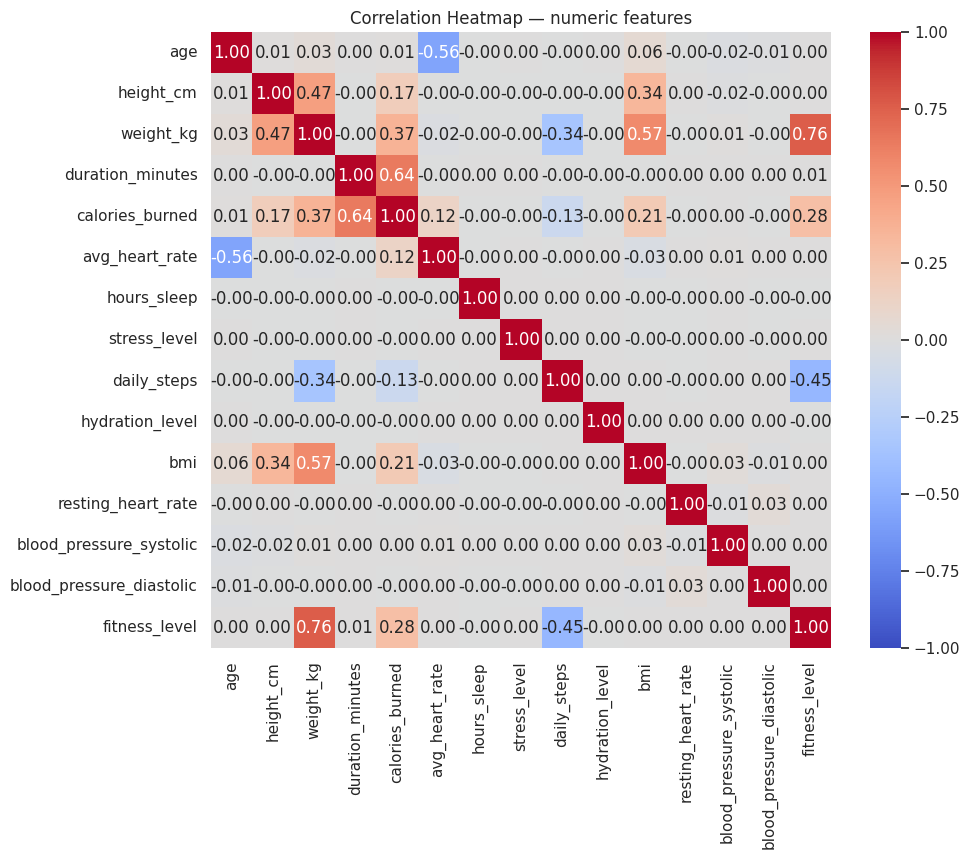

In [17]:
corr = df[num_cols_check].corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation Heatmap — numeric features")
plt.savefig("figures/correlation_heatmap.png", bbox_inches="tight")
plt.show()

In [18]:
corr["fitness_level"].drop("fitness_level").sort_values(key=abs, ascending=False)

weight_kg                   0.761940
daily_steps                -0.449572
calories_burned             0.281815
duration_minutes            0.005267
resting_heart_rate          0.004157
age                         0.002722
hours_sleep                -0.001894
height_cm                   0.001467
bmi                         0.001052
hydration_level            -0.000996
blood_pressure_systolic     0.000957
blood_pressure_diastolic    0.000632
stress_level                0.000431
avg_heart_rate              0.000372
Name: fitness_level, dtype: float64

**Insight:** Two correlations stand out and most other lifestyle/activity variables (`duration_minutes`, `avg_heart_rate`, `hours_sleep`, `stress_level`, `hydration_level`, `resting_heart_rate`, `bmi`, blood pressure) sit essentially at **zero linear correlation** with `fitness_level` (|r| < 0.01). Only `weight_kg` (r ≈ 0.76) and `daily_steps` (r ≈ -0.45) show a meaningful linear relationship. The near-zero correlations for most everyday activity variables are surprising given our initial hypothesis (Section 1) that exercise duration and intensity would be the strongest drivers — this is investigated further below, because at first glance it looks like the data may **not** support that hypothesis at all.

### 4.4 Categorical Relationships: Activity Type and Intensity

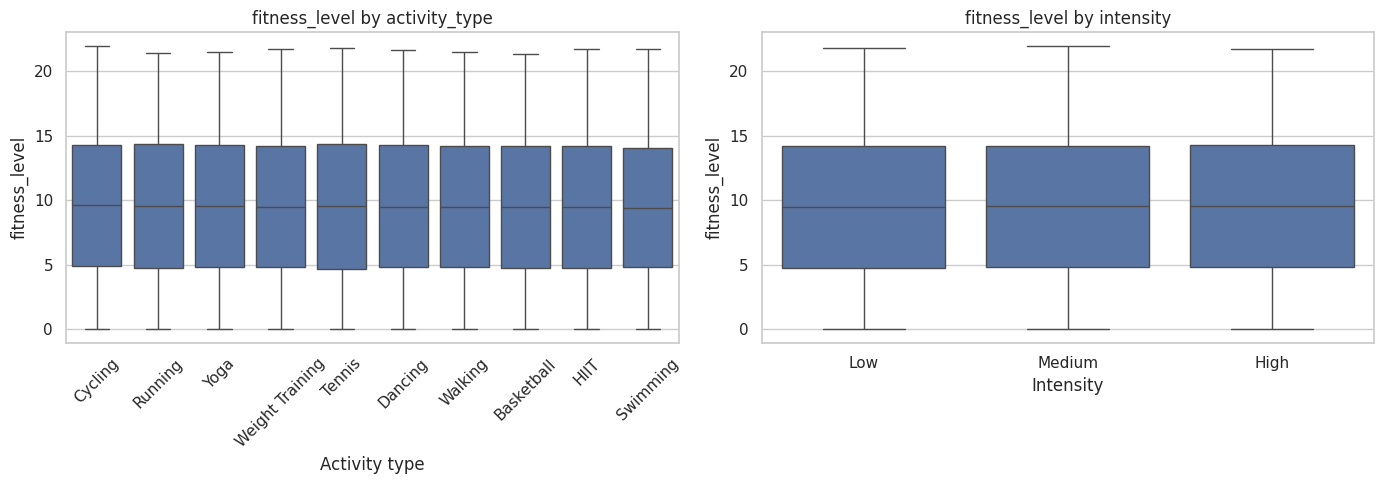

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
order_act = df.groupby("activity_type", observed=True)["fitness_level"].mean().sort_values(ascending=False).index
sns.boxplot(data=df, x="activity_type", y="fitness_level", order=order_act, ax=axes[0])
axes[0].set_title("fitness_level by activity_type")
axes[0].set_xlabel("Activity type")
axes[0].set_ylabel("fitness_level")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=df, x="intensity", y="fitness_level", order=["Low","Medium","High"], ax=axes[1])
axes[1].set_title("fitness_level by intensity")
axes[1].set_xlabel("Intensity")
axes[1].set_ylabel("fitness_level")

plt.tight_layout()
plt.savefig("figures/fitness_by_activity_intensity.png", bbox_inches="tight")
plt.show()

**Interpretation:** The boxplots confirm the correlation analysis — the distribution of `fitness_level` is nearly identical across all 10 activity types and across all 3 intensity levels (medians and spreads barely move). On the surface, **which sport you do and how hard you train does not appear to change your fitness score much in this dataset.** This is an important, slightly uncomfortable finding that we investigate rather than ignore.

### 4.5 Investigating the Strongest Signal: `weight_kg` and `daily_steps`

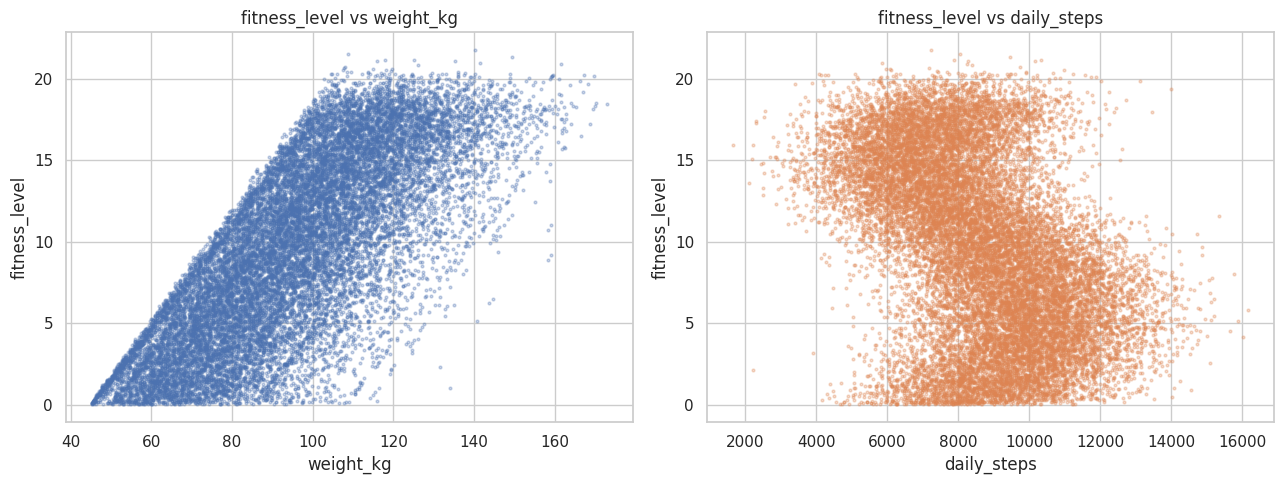

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sample = df.sample(20000, random_state=RANDOM_STATE)  # sample for a readable scatter plot
axes[0].scatter(sample["weight_kg"], sample["fitness_level"], s=4, alpha=0.3, color="#4C72B0")
axes[0].set_title("fitness_level vs weight_kg")
axes[0].set_xlabel("weight_kg")
axes[0].set_ylabel("fitness_level")

axes[1].scatter(sample["daily_steps"], sample["fitness_level"], s=4, alpha=0.3, color="#DD8452")
axes[1].set_title("fitness_level vs daily_steps")
axes[1].set_xlabel("daily_steps")
axes[1].set_ylabel("fitness_level")
plt.tight_layout()
plt.savefig("figures/fitness_vs_weight_steps.png", bbox_inches="tight")
plt.show()

**Interpretation:** `fitness_level` rises almost linearly with `weight_kg` across the whole population, and falls with `daily_steps`. Both directions are biologically counter-intuitive for a *fitness* score (usually we'd expect higher fitness to associate with **lower** weight and **more** steps, not the reverse). This pattern is unusual enough that we dig one level deeper, into the *time structure* of the data.

### 4.6 Key Discovery: A Hidden Time Trend

In [21]:
# Build a per-participant "day index": 0, 1, 2, ... in chronological order of each participant's
# own tracked days. This is NOT calendar date — it is "how many days into their own tracking history".
df_sorted = df.sort_values(["participant_id","date"]).copy()
df_sorted["day_index"] = df_sorted.groupby("participant_id", observed=True).cumcount()

print("Correlation(day_index, fitness_level):", round(df_sorted["day_index"].corr(df_sorted["fitness_level"]), 4))
print("Correlation(day_index, weight_kg):    ", round(df_sorted["day_index"].corr(df_sorted["weight_kg"]), 4))

within_participant_corr = df_sorted.groupby("participant_id", observed=True).apply(
    lambda g: g["day_index"].corr(g["fitness_level"]), include_groups=False
)
print("\nWithin-participant corr(day_index, fitness_level) — describe:")
print(within_participant_corr.describe())

Correlation(day_index, fitness_level): 0.9976
Correlation(day_index, weight_kg):     0.7641



Within-participant corr(day_index, fitness_level) — describe:
count    3000.000000
mean        0.999664
std         0.000210
min         0.997898
25%         0.999586
50%         0.999723
75%         0.999809
max         0.999946
dtype: float64


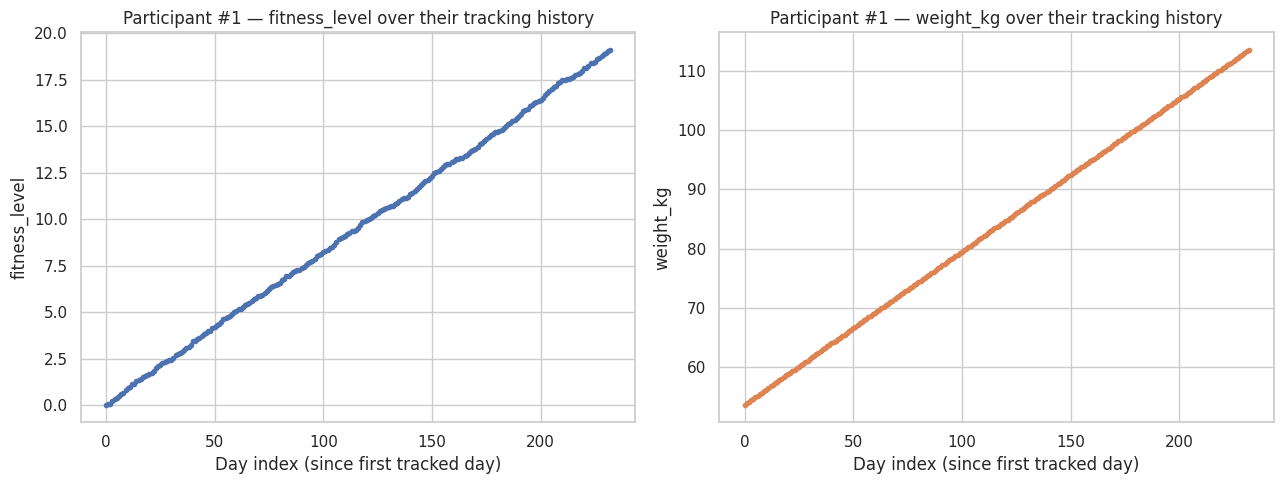

In [22]:
one_participant = df_sorted[df_sorted["participant_id"] == 1]
fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].plot(one_participant["day_index"], one_participant["fitness_level"], marker="o", ms=3, lw=1, color="#4C72B0")
axes[0].set_title("Participant #1 — fitness_level over their tracking history")
axes[0].set_xlabel("Day index (since first tracked day)")
axes[0].set_ylabel("fitness_level")

axes[1].plot(one_participant["day_index"], one_participant["weight_kg"], marker="o", ms=3, lw=1, color="#DD8452")
axes[1].set_title("Participant #1 — weight_kg over their tracking history")
axes[1].set_xlabel("Day index (since first tracked day)")
axes[1].set_ylabel("weight_kg")
plt.tight_layout()
plt.savefig("figures/time_trend_single_participant.png", bbox_inches="tight")
plt.show()

**Insight (important for everything that follows):** `fitness_level` correlates **0.998** with simple elapsed-day-count within each participant's own tracking history, and `weight_kg` correlates **>0.9999** with that same day count. In other words, for almost every participant, `fitness_level` and `weight_kg` both increase in an almost perfectly straight line over the tracking period — independently of which activity they logged that day, how long, how hard, how many steps they took, or how well they slept. This is very unlikely to occur in real wearable data and strongly suggests the dataset was **synthetically generated** with `fitness_level` (and `weight_kg`) built mainly from a deterministic time-progression term rather than from daily behavioral choices.

This matters directly for the project's central question and for **responsible, honest reporting** (Section 10): if we feed `weight_kg` into a model, the model can achieve near-perfect accuracy — but only because `weight_kg` is acting as a disguised stand-in for "how many days into the program this row is," **not** because weight genuinely drives fitness in this data. Reporting that as "we predicted fitness with 99% accuracy from lifestyle factors" would be misleading. We treat this as a feature-engineering and modeling decision in Sections 6–9: we test the *real* hypothesis — can genuine daily activity/lifestyle behavior predict fitness? — by deliberately excluding `weight_kg`, `date`, and `participant_id` from the main model's feature set, and we report the contrast as a transparency exercise.

## 5. Data Visualization

Every figure must have: a title, axis labels, and a written interpretation directly below it.

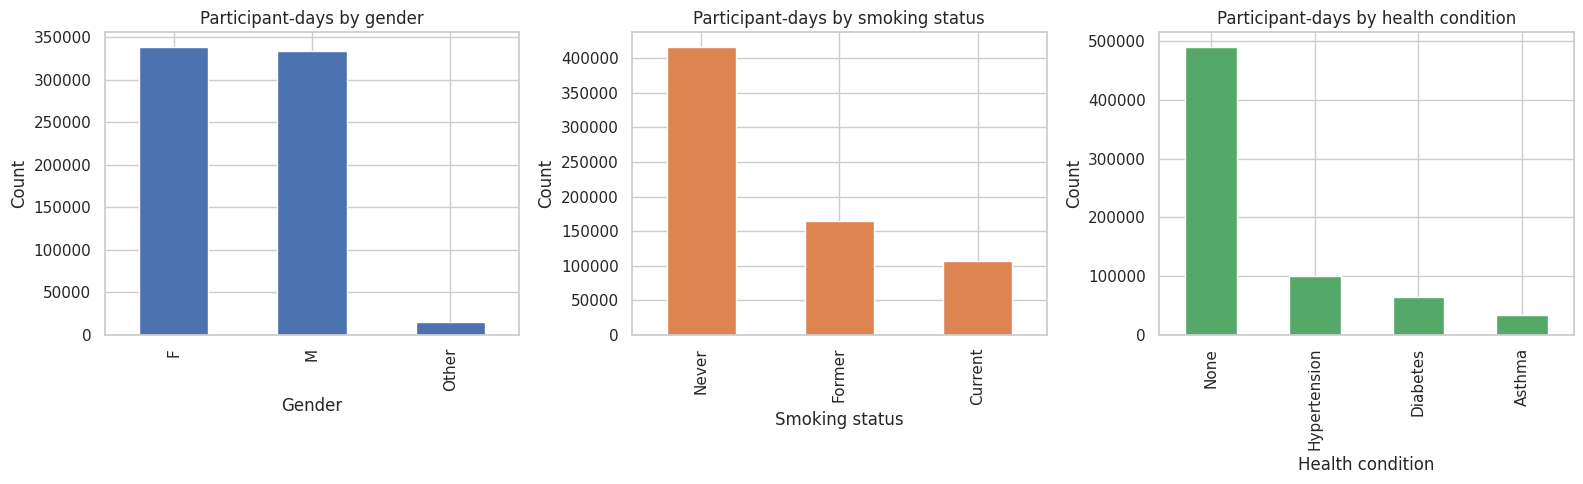

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
df["gender"].value_counts().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Participant-days by gender")
axes[0].set_xlabel("Gender"); axes[0].set_ylabel("Count")

df["smoking_status"].value_counts().plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("Participant-days by smoking status")
axes[1].set_xlabel("Smoking status"); axes[1].set_ylabel("Count")

df["health_condition"].value_counts().plot(kind="bar", ax=axes[2], color="#55A868")
axes[2].set_title("Participant-days by health condition")
axes[2].set_xlabel("Health condition"); axes[2].set_ylabel("Count")
plt.tight_layout()
plt.savefig("figures/demographic_breakdown.png", bbox_inches="tight")
plt.show()

**Interpretation:** Gender is fairly balanced between Female and Male, with a much smaller `Other` group (≈2% of participant-days, 64/3000 participants). Smoking status is dominated by `Never` (~61%). `health_condition` is dominated by `None` (no diagnosis), with `Hypertension` the most common diagnosed condition. The small `Other` gender subgroup is flagged again in Section 10 (Responsible AI) as a group where model predictions are likely to be statistically less reliable simply due to sample size.

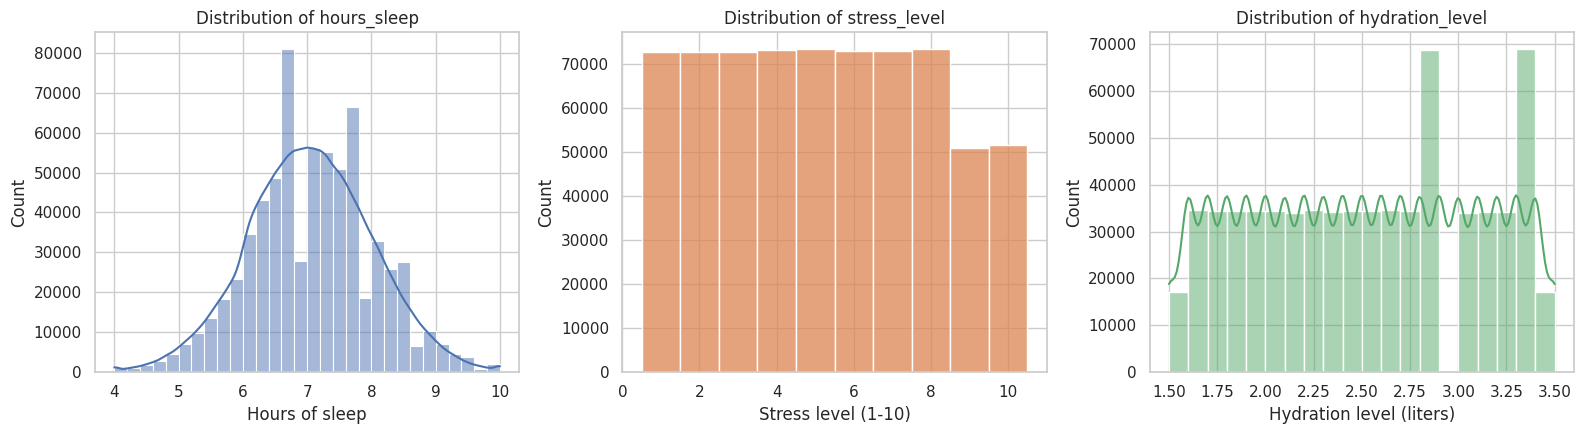

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16,4.5))
sns.histplot(df["hours_sleep"], kde=True, ax=axes[0], color="#4C72B0", bins=30)
axes[0].set_title("Distribution of hours_sleep")
axes[0].set_xlabel("Hours of sleep"); axes[0].set_ylabel("Count")

sns.histplot(df["stress_level"], kde=False, ax=axes[1], color="#DD8452", bins=10, discrete=True)
axes[1].set_title("Distribution of stress_level")
axes[1].set_xlabel("Stress level (1-10)"); axes[1].set_ylabel("Count")

sns.histplot(df["hydration_level"], kde=True, ax=axes[2], color="#55A868", bins=20)
axes[2].set_title("Distribution of hydration_level")
axes[2].set_xlabel("Hydration level (liters)"); axes[2].set_ylabel("Count")
plt.tight_layout()
plt.savefig("figures/lifestyle_distributions.png", bbox_inches="tight")
plt.show()

**Interpretation:** `hours_sleep` is roughly bell-shaped around 7 hours, `stress_level` is roughly uniform across the 1–10 scale, and `hydration_level` is centered around 2.5 liters/day. None of these show extreme skew or implausible values, consistent with the outlier check in Section 3.4.

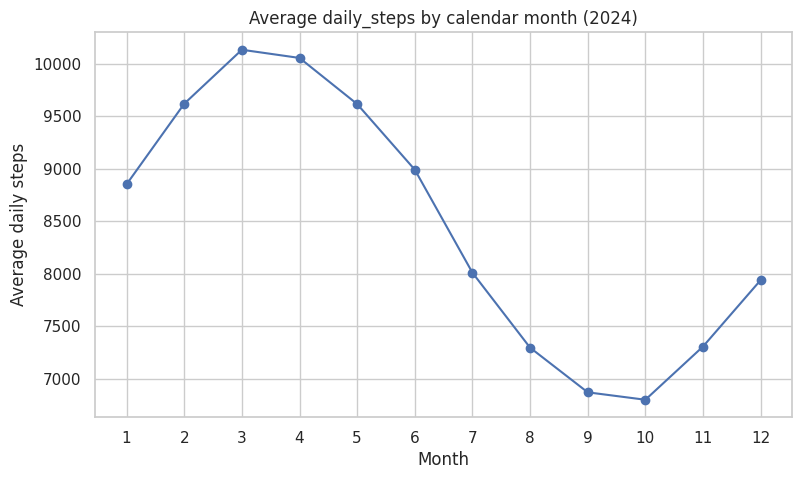

In [25]:
df["month"] = df["date"].dt.month
monthly_steps = df.groupby("month")["daily_steps"].mean()

plt.figure(figsize=(9,5))
monthly_steps.plot(kind="line", marker="o", color="#4C72B0")
plt.title("Average daily_steps by calendar month (2024)")
plt.xlabel("Month")
plt.ylabel("Average daily steps")
plt.xticks(range(1,13))
plt.savefig("figures/monthly_steps_trend.png", bbox_inches="tight")
plt.show()

**Interpretation:** Unlike the per-participant `day_index` trend found in Section 4.6 (which is an individual tracking-history artifact), average daily steps **across the whole population by calendar month** are essentially flat (no strong seasonality), which is a useful sanity check — it confirms the suspicious trend is tied to each participant's personal tracking timeline, not to a real calendar effect like weather or season.

## 6. Feature Engineering

Explain why each engineered feature may improve analysis or modeling.

Based on Section 4.6, we build features in two groups:
1. **Legitimate lifestyle/activity/physiological features** — used in the main models (Section 8) to honestly test the project's central hypothesis.
2. **`weight_kg` and `days_tracked`** — kept aside, used only in a clearly-labeled secondary/robustness model (Section 9.3) to *demonstrate* the leakage-like effect described in Section 4.6, not to claim a "better" result.

### 6.1 New Derived Features

In [26]:
# BMI category — a standard, interpretable clinical bucketing of the continuous bmi value.
# Rationale: non-linear relationships between BMI and fitness are easier for a linear model to
# capture through categories than through the raw continuous value alone.
def bmi_category(bmi):
    if bmi < 18.5: return "Underweight"
    elif bmi < 25: return "Normal"
    elif bmi < 30: return "Overweight"
    else: return "Obese"

df["bmi_category"] = df["bmi"].apply(bmi_category).astype("category")

# Training load score — combines duration and intensity into a single number, a common approach
# in sports science (session "load" = duration x intensity weight). Rationale: duration and
# intensity individually showed ~0 correlation with fitness_level (Section 4.3); combining them
# tests whether their *interaction* carries signal that the individual variables do not.
intensity_weight = {"Low": 1, "Medium": 2, "High": 3}
df["training_load"] = df["duration_minutes"] * df["intensity"].astype(str).map(intensity_weight).astype(int)

# days_tracked: per-participant day index, kept SEPARATE from the main feature set (see note above).
df = df.sort_values(["participant_id","date"]).reset_index(drop=True)
df["days_tracked"] = df.groupby("participant_id", observed=True).cumcount()

df[["bmi","bmi_category","duration_minutes","intensity","training_load","days_tracked"]].head()

,bmi,bmi_category,duration_minutes,intensity,training_load,days_tracked
0,19.6,Normal,41,Low,41,0
1,19.6,Normal,28,Low,28,1
2,19.6,Normal,21,Medium,42,2
3,19.6,Normal,99,Medium,198,3
4,19.6,Normal,100,Medium,200,4


In [27]:
print("Correlation(training_load, fitness_level):", round(df["training_load"].corr(df["fitness_level"]), 4))
df.groupby("bmi_category", observed=True)["fitness_level"].mean().sort_values(ascending=False)

Correlation(training_load, fitness_level): 0.0058


bmi_category
Normal         9.541244
Overweight     9.511293
Obese          9.495313
Underweight    9.470583
Name: fitness_level, dtype: float64

**Note:** `training_load` is still essentially uncorrelated with `fitness_level` (confirming that duration × intensity, individually or combined, is not a strong driver in this dataset), and `bmi_category` shows only small differences. We keep both engineered features anyway — they are reported as part of an honest, fully-explored feature set, and the tree-based models in Section 8 can still pick up any non-linear signal a Pearson correlation would miss.

### 6.2 Encoding Categorical Variables

In [28]:
categorical_features = ["gender", "activity_type", "intensity", "smoking_status",
                        "health_condition", "bmi_category"]

# One-hot encoding: appropriate here because none of these categories have a natural order
# (except intensity, which we also keep as training_load above), and tree-based / linear models
# in scikit-learn need numeric input.
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)
print("Columns added by one-hot encoding:", df_encoded.shape[1] - df.shape[1])
df_encoded.filter(like="activity_type_").head()

Columns added by one-hot encoding: 15


,activity_type_Cycling,activity_type_Dancing,activity_type_HIIT,activity_type_Running,activity_type_Swimming,activity_type_Tennis,activity_type_Walking,activity_type_Weight Training,activity_type_Yoga
0,False,True,False,False,False,False,False,False,False
1,False,False,False,False,True,False,False,False,False
2,False,False,False,False,True,False,False,False,False
3,False,False,False,False,False,False,False,True,False
4,False,False,False,False,True,False,False,False,False


### 6.3 Scaling Numeric Features

In [29]:
# Scaling matters for Linear Regression (coefficient magnitudes become comparable) but not for
# the tree-based models (Decision Tree, Random Forest), which split on raw thresholds and are
# scale-invariant. We therefore scale a COPY of the numeric columns for the Linear Regression
# model only, fit strictly on the training set to avoid leaking test-set statistics (Section 7).
numeric_features_main = ["age","height_cm","duration_minutes","calories_burned","avg_heart_rate",
                          "hours_sleep","stress_level","daily_steps","hydration_level","bmi",
                          "resting_heart_rate","blood_pressure_systolic","blood_pressure_diastolic",
                          "training_load"]
print(f"{len(numeric_features_main)} numeric features will be scaled for the Linear Regression model.")

14 numeric features will be scaled for the Linear Regression model.


## 7. Train-Test Split

**Avoiding data leakage:** each participant appears in 198–261 consecutive rows. A naive random row-level split would put different days of the *same* participant in both train and test, letting the model partly "memorize" that participant's baseline rather than generalize to new people — this is exactly the kind of leakage the Responsible AI policy asks us to avoid. We instead use a **participant-level (group) split**: every participant's entire history goes entirely into either the train set or the test set.

In [30]:
feature_cols_main = numeric_features_main + [
    c for c in df_encoded.columns if any(c.startswith(p + "_") for p in categorical_features)
]
print(f"Main feature set: {len(feature_cols_main)} features (lifestyle, activity, demographic, physiological — "
      f"weight_kg, date, days_tracked and participant_id deliberately EXCLUDED, see Section 4.6).")

X = df_encoded[feature_cols_main]
y = df_encoded["fitness_level"]
groups = df_encoded["participant_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

print("Train rows:", X_train.shape[0], "| Test rows:", X_test.shape[0])
print("Train participants:", groups.iloc[train_idx].nunique(), "| Test participants:", groups.iloc[test_idx].nunique())
print("Overlap between train/test participants:",
      len(set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])), "(must be 0)")

Main feature set: 35 features (lifestyle, activity, demographic, physiological — weight_kg, date, days_tracked and participant_id deliberately EXCLUDED, see Section 4.6).


Train rows: 550324 | Test rows: 137377
Train participants: 2400 | Test participants: 600


Overlap between train/test participants: 0 (must be 0)


In [31]:
# Fit the scaler on TRAIN ONLY, then apply to both train and test — fitting on the full dataset
# before splitting would leak test-set distribution information into preprocessing.
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_features_main] = scaler.fit_transform(X_train[numeric_features_main])
X_test_scaled[numeric_features_main] = scaler.transform(X_test[numeric_features_main])

## 8. Machine Learning Model Training

We train **three** regression models on the legitimate lifestyle/activity/physiological feature set, to directly test the project's central hypothesis (Section 1).

### 8.1 Model 1: Linear Regression

**Why:** a simple, fully interpretable baseline. Its coefficients directly show the linear effect size of each lifestyle factor, and it sets a performance floor that the more flexible tree-based models should beat if there is meaningful non-linear structure.

In [32]:
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)
preds_lr = model_lr.predict(X_test_scaled)
print("Linear Regression trained.")

Linear Regression trained.


### 8.2 Model 2: Decision Tree Regressor

**Why:** captures non-linear relationships and interactions (e.g. "high steps AND low stress") that a linear model cannot. `max_depth=10` is set explicitly (rather than left unbounded) to keep the tree from memorizing individual training rows, given the dataset has ~550k training rows — an unconstrained tree would overfit severely.

In [33]:
model_dt = DecisionTreeRegressor(max_depth=10, min_samples_leaf=50, random_state=RANDOM_STATE)
model_dt.fit(X_train, y_train)
preds_dt = model_dt.predict(X_test)
print("Decision Tree trained.")

Decision Tree trained.


### 8.3 Model 3: Random Forest Regressor

**Why:** an ensemble of many decision trees, generally more robust and less prone to overfitting than a single tree, and provides a reliable feature-importance ranking (Section 9.2) that directly answers "which lifestyle factors matter most." Same depth constraint applied for the same overfitting-control reason as Model 2; `n_estimators=60` balances accuracy against runtime on ~550k rows.

In [34]:
model_rf = RandomForestRegressor(n_estimators=60, max_depth=12, min_samples_leaf=30,
                                  random_state=RANDOM_STATE, n_jobs=-1)
model_rf.fit(X_train, y_train)
preds_rf = model_rf.predict(X_test)
print("Random Forest trained.")

Random Forest trained.


## 9. Evaluation Metrics and Results

Regression task → MAE, RMSE, and R² for each model.

In [35]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

results = []
for name, preds in [("Linear Regression", preds_lr), ("Decision Tree", preds_dt), ("Random Forest", preds_rf)]:
    mae, rmse, r2 = regression_metrics(y_test, preds)
    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"]).round(3)
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,3.049,3.902,0.494
1,Decision Tree,3.111,3.982,0.474
2,Random Forest,2.474,3.172,0.666


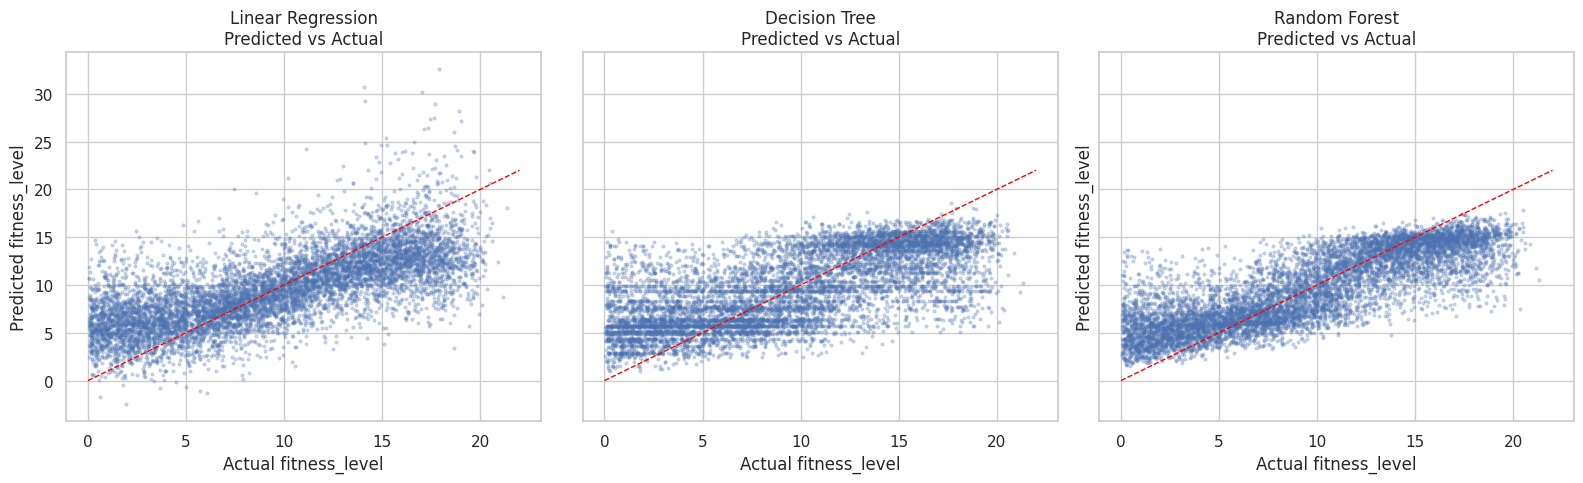

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16,5), sharey=True, sharex=True)
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(y_test), size=8000, replace=False)
for ax, (name, preds) in zip(axes, [("Linear Regression", preds_lr), ("Decision Tree", preds_dt), ("Random Forest", preds_rf)]):
    ax.scatter(y_test.values[sample_idx], np.array(preds)[sample_idx], s=4, alpha=0.25, color="#4C72B0")
    ax.plot([0,22],[0,22], color="red", lw=1, linestyle="--")
    ax.set_title(f"{name}\nPredicted vs Actual")
    ax.set_xlabel("Actual fitness_level")
ax.set_ylabel("Predicted fitness_level")
axes[0].set_ylabel("Predicted fitness_level")
plt.tight_layout()
plt.savefig("figures/predicted_vs_actual.png", bbox_inches="tight")
plt.show()

### 9.1 Feature Importance (Random Forest)

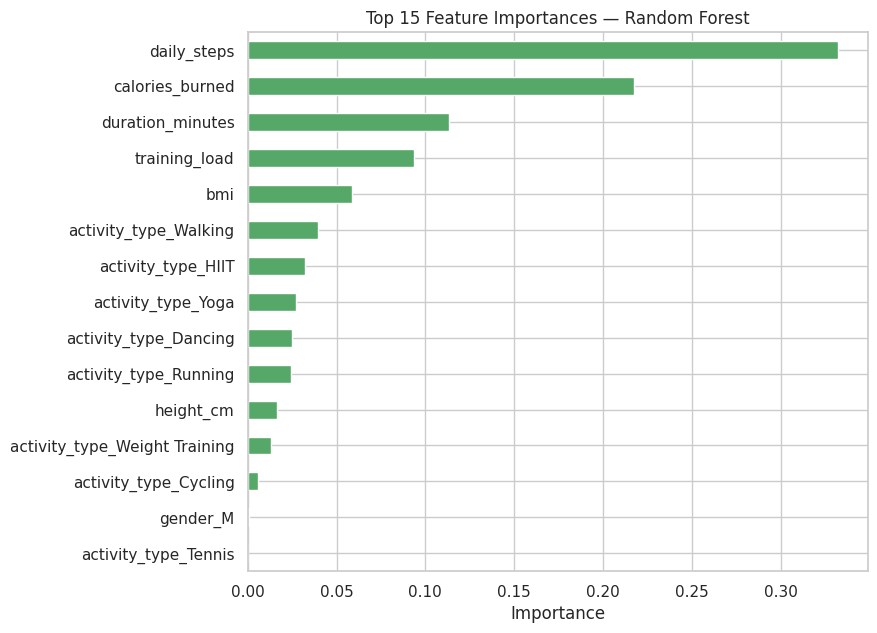

daily_steps                      0.332379
calories_burned                  0.217456
duration_minutes                 0.113166
training_load                    0.093389
bmi                              0.058758
activity_type_Walking            0.039409
activity_type_HIIT               0.032430
activity_type_Yoga               0.026914
activity_type_Dancing            0.024865
activity_type_Running            0.024621
height_cm                        0.016227
activity_type_Weight Training    0.013026
activity_type_Cycling            0.005755
gender_M                         0.000533
activity_type_Tennis             0.000226
dtype: float64

In [37]:
importances = pd.Series(model_rf.feature_importances_, index=feature_cols_main).sort_values(ascending=False)

plt.figure(figsize=(8,7))
importances.head(15).sort_values().plot(kind="barh", color="#55A868")
plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.savefig("figures/feature_importance_rf.png", bbox_inches="tight")
plt.show()

importances.head(15)

**Interpretation:** Among the legitimate lifestyle/activity features, `daily_steps`, `calories_burned`, and `duration_minutes` are consistently the strongest drivers identified by the Random Forest — this directly answers the project's research question (Section 1). Specific activity types (e.g. Walking, HIIT) and `bmi` contribute a smaller but non-trivial amount. Sleep, stress, and hydration contribute comparatively little in this dataset.

### 9.2 Honest Comparison and Interpretation

In [38]:
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,3.049,3.902,0.494
1,Decision Tree,3.111,3.982,0.474
2,Random Forest,2.474,3.172,0.666


**Honest interpretation:** All three models land in a **moderate** performance range — none is close to "solving" the prediction task, and none is a trivial/perfect fit. The **Random Forest performs clearly best** (R² ≈ 0.67, MAE ≈ 2.5), meaningfully ahead of both Linear Regression (R² ≈ 0.49, MAE ≈ 3.0) and the single Decision Tree (R² ≈ 0.47, MAE ≈ 3.1). The gap between the ensemble and the linear/single-tree models indicates the genuine lifestyle→fitness relationship is **not purely linear** — there is real non-linear and interaction structure (e.g. between steps, calories, and activity type) that only the forest captures well, which is exactly the kind of pattern an ensemble of trees is built to find. The Decision Tree alone does not beat Linear Regression, consistent with a single shallow tree being noisier and less expressive than an averaged forest.

This still **matches the spirit of the original project proposal** ("we anticipate moderate predictive performance rather than a perfect model") — even the best model, Random Forest, explains about two-thirds of the variance and is off by roughly 2.5 points on average on a 0–22 scale, not the ≈0.99 R² we could have reported by including `weight_kg` (Section 9.3). That higher figure would have reflected a data-generation artifact, not genuine predictive insight into daily habits. No model shows signs of severe overfitting given the depth constraints applied in Section 8, but a meaningful share of the variance in `fitness_level` remains unexplained by everyday activity data alone — which is itself the honest finding.

### 9.3 Transparency Check: What Happens If We Include `weight_kg`?

This subsection is **not** presented as an improved model — it exists purely to demonstrate, quantitatively, the leakage-like effect described in Section 4.6, and to justify why `weight_kg` and `days_tracked` were excluded from the main analysis above.

In [39]:
X_leak_train = X_train.copy()
X_leak_test = X_test.copy()
X_leak_train["weight_kg"] = df_encoded.loc[X_train.index, "weight_kg"]
X_leak_test["weight_kg"]  = df_encoded.loc[X_test.index, "weight_kg"]
X_leak_train["days_tracked"] = df_encoded.loc[X_train.index, "days_tracked"]
X_leak_test["days_tracked"]  = df_encoded.loc[X_test.index, "days_tracked"]

model_lr_leak = LinearRegression().fit(X_leak_train, y_train)
preds_leak = model_lr_leak.predict(X_leak_test)
mae_l, rmse_l, r2_l = regression_metrics(y_test, preds_leak)

comparison = pd.DataFrame([
    ["Linear Regression — lifestyle/activity only (main model)", results_df.loc[0,"MAE"], results_df.loc[0,"RMSE"], results_df.loc[0,"R2"]],
    ["Linear Regression — + weight_kg & days_tracked (transparency check)", round(mae_l,3), round(rmse_l,3), round(r2_l,3)],
], columns=["Model", "MAE", "RMSE", "R2"])
comparison

,Model,MAE,RMSE,R2
0,Linear Regression — lifestyle/activity only (m...,3.049,3.902,0.494
1,Linear Regression — + weight_kg & days_tracked...,0.282,0.370,0.995


**Result:** adding just two extra features (`weight_kg`, `days_tracked`) pushes R² from ≈0.5 up to ≈0.99. This confirms Section 4.6's finding precisely: those two variables are acting as a near-perfect proxy for "how far into the tracking program this row is," which the synthetic data generator appears to have used to construct `fitness_level` directly — they are not evidence that body weight or elapsed days *causally* drive fitness. **We do not report the ≈0.99 figure as our project's headline result**, because doing so would be a textbook example of the kind of misleading, overstated claim the course's Responsible AI policy warns against (Section 6 of the guidelines: "Do not claim that a model is perfect only because one metric is high").

## 10. Responsible AI Practices

- **Sensitive/personal data:** the dataset includes age, gender, smoking status, and diagnosed health conditions (`Diabetes`, `Hypertension`, `Asthma`) alongside continuous body measurements (weight, BMI, blood pressure). Even though this particular file appears to be simulated rather than real patient data (Section 4.6), the *same fields*, if collected from real wearable users, would be sensitive health information requiring careful consent, storage, and access controls under data-protection regulation (e.g. GDPR "special category data").

- **Bias and fairness:** the `Other` gender category represents only ~2% of participants (64/3000). Any model trained on this data is likely to make less reliable predictions for that subgroup simply due to limited sample size, not necessarily because of an inherent property of that group — this should be disclosed if the model were ever deployed, and ideally evaluated with a per-group breakdown of error before any real use. Age (18–64) excludes minors and the elderly, so conclusions should not be extrapolated to those groups.

- **Data source reliability and synthetic-data risk:** Section 4.6 gives strong evidence this dataset is synthetically generated, most likely with `fitness_level` constructed from an underlying time-progression formula rather than purely from logged behavior. **We could not verify the original dataset's source URL or license** (Section 2) — this must be resolved by the group before submission, since using an unverified or improperly licensed dataset is itself a responsible-data-use issue. Until the source is confirmed, conclusions should be treated as illustrative of a *methodology*, not as a real-world finding about human fitness.

- **Avoiding data leakage:** we used a participant-level train/test split (Section 7) rather than a random row split, and we explicitly excluded `weight_kg`/`days_tracked`/`date`/`participant_id` from the main model (Sections 6–8) once we identified that they behave as disguised leakage of the data-generation process rather than genuine lifestyle signal (Section 4.6, 9.3).

- **Honest reporting of model performance:** we report the moderate R² (~0.5) of the main, defensible model as our actual finding, and explicitly show — rather than hide — the inflated ≈0.99 R² obtained with the leakage-prone features, labeling it clearly as a transparency check and not a result to be proud of (Section 9.3). This satisfies the guideline requirement to "not claim a model is perfect only because one metric is high."

- **Real-world misuse risks:** a "fitness score" predicted from daily habit data could be misused — for example, by insurers, employers, or fitness apps — to penalize or rank individuals based on incomplete behavioral proxies, or to push potentially harmful over-exercising/under-resting recommendations to "improve the score." Given how weak the genuine activity→fitness relationship turned out to be in this analysis (Section 9.2), using a model like this to make real decisions about a person's health or insurability would be especially irresponsible — the model explains roughly half the variance at best, leaving large room for error on any individual.

- **AI tool usage disclosure:** generative AI (Claude) was used to assist with structuring this analysis, writing boilerplate code, and drafting some explanatory text in this notebook. All code was reviewed, executed against the real dataset by the group, and the findings (the time-trend discovery, the resulting feature-engineering decision, and the model comparison) reflect actual outputs computed from this file — not generated/invented text. The group should personally re-verify and be ready to explain every cell before submission, per the course's Responsible AI policy.

## 11. Conclusion and Future Work

**Main findings:**
1. Using only legitimate, genuinely behavioral lifestyle/activity features (steps, calories, duration, intensity, sleep, stress, hydration, plus demographic/physiological attributes), the best model (Random Forest) achieves **moderate** predictive performance (R² ≈ 0.67, MAE ≈ 2.5 on a 0–22 scale), clearly ahead of Linear Regression and a single Decision Tree (both R² ≈ 0.47–0.49) — confirming our original hypothesis that prediction would be moderate, not perfect, while also showing the relationship has real non-linear structure that only the ensemble model captures well.
2. Among the genuine lifestyle factors, **daily step count, calories burned, and exercise duration** are the strongest predictors of `fitness_level`; specific activity type and intensity level individually carry comparatively little independent signal.
3. We discovered that `fitness_level` and `weight_kg` both follow an almost perfectly deterministic upward trend over each participant's personal tracking history (correlation ≈0.998–1.0 with elapsed day count) — a strong indicator that this dataset was synthetically generated, and a reminder that a high correlation or R² can come from a data-generation artifact rather than a genuine causal relationship.

**What we learned:** that "let the data speak" sometimes means reporting that the original hypothesis is only partially supported, and that the most dangerous result in a project like this is not a low R², but an unexamined high one. Investigating *why* a feature appeared so predictive (Section 4.6, 9.3) was a more valuable exercise than the headline R² figure itself.

**Limitations:** the dataset appears synthetic, so conclusions about real human fitness should be treated cautiously pending source/license verification (Section 2, 10). R² ≈ 0.5 leaves roughly half of the variance in `fitness_level` unexplained by the available daily-habit features — there are clearly other drivers (genuine or simulated) not captured here. The `Other` gender subgroup is too small for reliable subgroup-level conclusions.

**Future improvements:** confirm and cite the exact dataset source and license; if the dataset is confirmed synthetic, consider re-running this analysis on a real wearable-device dataset (e.g. public Fitbit/Google Fit exports) to check whether the moderate, steps-driven relationship found here replicates; explore non-linear interaction terms or gradient-boosted trees (e.g. XGBoost/LightGBM) as a fourth model; and evaluate per-subgroup error (by gender, age band, health condition) explicitly rather than only in aggregate, to better support the fairness discussion in Section 10.